# 🎯 YOLOv8 - Détection Véhicule

**Objectif** : Entraîner YOLOv8 pour détecter et cropper les véhicules

**Usage** : Pré-traitement avant classification EfficientNet

---

## 📦 Imports

In [1]:
from ultralytics import YOLO
import pandas as pd
import json
from pathlib import Path
import shutil
from tqdm import tqdm
import cv2
import sys

sys.path.insert(0, '.')
from src.dataset import convert_bbox_to_yolo, prepare_yolo_dataset

print('✅ Imports OK')

✅ Imports OK


## 🔧 Configuration

In [2]:
# Paths
DATA_DIR = Path('data/stanford_cars')
YOLO_DIR = DATA_DIR / 'yolo_vehicle_detection'
MODELS_DIR = Path('models/yolo_vehicle_detector')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'📁 Dataset YOLO sera créé dans: {YOLO_DIR}')
print(f'📁 Modèle sera sauvegardé dans: {MODELS_DIR}')

📁 Dataset YOLO sera créé dans: data/stanford_cars/yolo_vehicle_detection
📁 Modèle sera sauvegardé dans: models/yolo_vehicle_detector


In [3]:
# Configuration entraînement YOLO
YOLO_CONFIG = {
    'model': 'yolov8n.pt',      # Nano (rapide)
    'epochs': 30,               # 30 epochs suffisant
    'imgsz': 640,
    'batch': 16,
    'patience': 10,
    'device': 0,                # GPU
    'workers': 4,
}

print('⚙️  Configuration:')
for key, value in YOLO_CONFIG.items():
    print(f'   {key}: {value}')

⚙️  Configuration:
   model: yolov8n.pt
   epochs: 30
   imgsz: 640
   batch: 16
   patience: 10
   device: 0
   workers: 4


## 📊 Préparation Dataset YOLO

On va convertir Stanford Cars en format YOLO avec **une seule classe : vehicle**

In [4]:
# Charger annotations
annotations_file = DATA_DIR / 'train_annotations.csv'
df_annos = pd.read_csv(annotations_file)

# Convertir bbox si nécessaire
if isinstance(df_annos['bbox'].iloc[0], str):
    import ast
    df_annos['bbox'] = df_annos['bbox'].apply(ast.literal_eval)

print(f'✅ {len(df_annos)} annotations chargées')
print(f'📊 Classes originales: {df_annos["class_id"].nunique()}')
print(f'📊 Classes YOLO: 1 (vehicle)')

✅ 8144 annotations chargées
📊 Classes originales: 196
📊 Classes YOLO: 1 (vehicle)


In [5]:
# Charger class_names
with open(DATA_DIR / 'class_names.json') as f:
    class_names = json.load(f)

print(f'✅ {len(class_names)} noms de classes chargés')

✅ 196 noms de classes chargés


### Créer Dataset YOLO Format

In [6]:
# Utiliser fonction existante pour créer dataset YOLO
print('🔨 Création dataset YOLO...')

yolo_dataset_dir, yaml_path = prepare_yolo_dataset(
    df_annos,
    DATA_DIR / 'cars_train',
    DATA_DIR,
    class_names,
    test_size=0.15
)

print(f'\n✅ Dataset YOLO créé: {yolo_dataset_dir}')
print(f'✅ Config YAML: {yaml_path}')

🔨 Création dataset YOLO...

📦 Préparation split 'train': 6922 images


Processing train: 100%|██████████| 6922/6922 [04:59<00:00, 23.14it/s]



📦 Préparation split 'val': 1222 images


Processing val: 100%|██████████| 1222/1222 [00:53<00:00, 22.83it/s]


✅ Dataset YOLO créé: data/stanford_cars/yolo_vehicle_detection
📄 Configuration: data/stanford_cars/yolo_vehicle_detection/data.yaml

✅ Dataset YOLO créé: data/stanford_cars/yolo_vehicle_detection
✅ Config YAML: data/stanford_cars/yolo_vehicle_detection/data.yaml


In [7]:
# Vérifier structure
print('\n📁 Structure dataset YOLO:')
print(f'Train images: {len(list((yolo_dataset_dir / "train" / "images").glob("*.jpg")))}')
print(f'Train labels: {len(list((yolo_dataset_dir / "train" / "labels").glob("*.txt")))}')
print(f'Val images: {len(list((yolo_dataset_dir / "val" / "images").glob("*.jpg")))}')
print(f'Val labels: {len(list((yolo_dataset_dir / "val" / "labels").glob("*.txt")))}')


📁 Structure dataset YOLO:
Train images: 6922
Train labels: 6922
Val images: 1222
Val labels: 1222


In [8]:
# Afficher contenu data.yaml
print('\n📄 Contenu data.yaml:')
with open(yaml_path) as f:
    print(f.read())


📄 Contenu data.yaml:
# YOLOv8 Vehicle Detection Dataset
path: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/data/stanford_cars/yolo_vehicle_detection
train: train/images
val: val/images

# Classes
nc: 1
names: ['vehicle']



## 🚀 Entraînement YOLOv8

**Durée estimée** : 20-30 min

In [9]:
# Charger modèle YOLOv8 nano pré-entraîné
model = YOLO(YOLO_CONFIG['model'])

print(f'✅ Modèle {YOLO_CONFIG["model"]} chargé')
print(f'📊 Architecture: YOLOv8 Nano')
print(f'⚡ Rapide et léger (6MB)')

✅ Modèle yolov8n.pt chargé
📊 Architecture: YOLOv8 Nano
⚡ Rapide et léger (6MB)


In [10]:
# LANCER ENTRAÎNEMENT
print('='*60)
print('🚀 DÉMARRAGE ENTRAÎNEMENT YOLO')
print('='*60)

results = model.train(
    data=str(yaml_path),
    epochs=YOLO_CONFIG['epochs'],
    imgsz=YOLO_CONFIG['imgsz'],
    batch=YOLO_CONFIG['batch'],
    patience=YOLO_CONFIG['patience'],
    device=YOLO_CONFIG['device'],
    workers=YOLO_CONFIG['workers'],
    project=str(MODELS_DIR),
    name='vehicle_detector',
    exist_ok=True,
    pretrained=True,
    optimizer='Adam',
    verbose=True,
    plots=True,
    save=True,
    save_period=5,
)

print('\n🎉 ENTRAÎNEMENT TERMINÉ!')

🚀 DÉMARRAGE ENTRAÎNEMENT YOLO
New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/stanford_cars/yolo_vehicle_detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yol

## 📊 Validation et Métriques

In [14]:
# Validation sur val set
print('📊 Validation sur val set...')

metrics = model.val(
    data=str(yaml_path),
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.6,
)

print('\n' + '='*60)
print('📊 MÉTRIQUES YOLO')
print('='*60)
print(f'mAP50: {metrics.box.map50:.4f}')
print(f'mAP50-95: {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall: {metrics.box.mr:.4f}')
print('='*60)

📊 Validation sur val set...
Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)


val: Fast image access ✅ (ping: 3.6±0.5 ms, read: 8.7±9.3 MB/s, size: 58.1 KB)
val: Scanning /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/data/stanford_cars/yolo_vehicle_detection/val/labels.cache... 1222 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1222/1222 222.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 77/77 4.7it/s 16.4s0.2s
                   all       1222       1222      0.988      0.998      0.995      0.993
Speed: 1.1ms preprocess, 2.2ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/runs/detect/val2

📊 MÉTRIQUES YOLO
mAP50: 0.9946
mAP50-95: 0.9934
Precision: 0.9878
Recall: 0.9975


In [20]:
# YOLO crée automatiquement ce chemin
best_model_path = Path('runs/detect/models/yolo_vehicle_detector/vehicle_detector/weights/best.pt')

# OU chercher dans le dossier MODELS_DIR si configuré
# best_model_path = MODELS_DIR / 'vehicle_detector' / 'weights' / 'best.pt'

print(f'🔍 Recherche modèle dans: {best_model_path}')

# Vérifier existence
if not best_model_path.exists():
    # Chercher dans runs/
    alt_path = Path('runs/detect/train/weights/best.pt')
    if alt_path.exists():
        best_model_path = alt_path
        print(f'✅ Modèle trouvé: {best_model_path}')
    else:
        print('❌ Modèle introuvable!')
        print('Chemins vérifiés:')
        print(f'  - {MODELS_DIR / "vehicle_detector" / "weights" / "best.pt"}')
        print(f'  - {alt_path}')
else:
    print(f'✅ Modèle trouvé: {best_model_path}')

print(f'\n✅ Meilleur modèle sauvegardé:')
print(f'   {best_model_path}')
print(f'\n📊 Résultats et graphiques dans:')
print(f'   {MODELS_DIR / "vehicle_detector"}')

🔍 Recherche modèle dans: runs/detect/models/yolo_vehicle_detector/vehicle_detector/weights/best.pt
✅ Modèle trouvé: runs/detect/models/yolo_vehicle_detector/vehicle_detector/weights/best.pt

✅ Meilleur modèle sauvegardé:
   runs/detect/models/yolo_vehicle_detector/vehicle_detector/weights/best.pt

📊 Résultats et graphiques dans:
   models/yolo_vehicle_detector/vehicle_detector


## 🧪 Test du Modèle

In [21]:
# Charger meilleur modèle
best_model = YOLO(str(best_model_path))
print(f'✅ Meilleur modèle chargé depuis: {best_model_path}')

✅ Meilleur modèle chargé depuis: runs/detect/models/yolo_vehicle_detector/vehicle_detector/weights/best.pt


🔍 Test sur 6 images
Image 1: 00000.jpg → 2 détection(s)
Image 2: 00001.jpg → 2 détection(s)
Image 3: 00002.jpg → 2 détection(s)
Image 4: 00003.jpg → 2 détection(s)
Image 5: 00004.jpg → 2 détection(s)
Image 6: 00005.jpg → 2 détection(s)


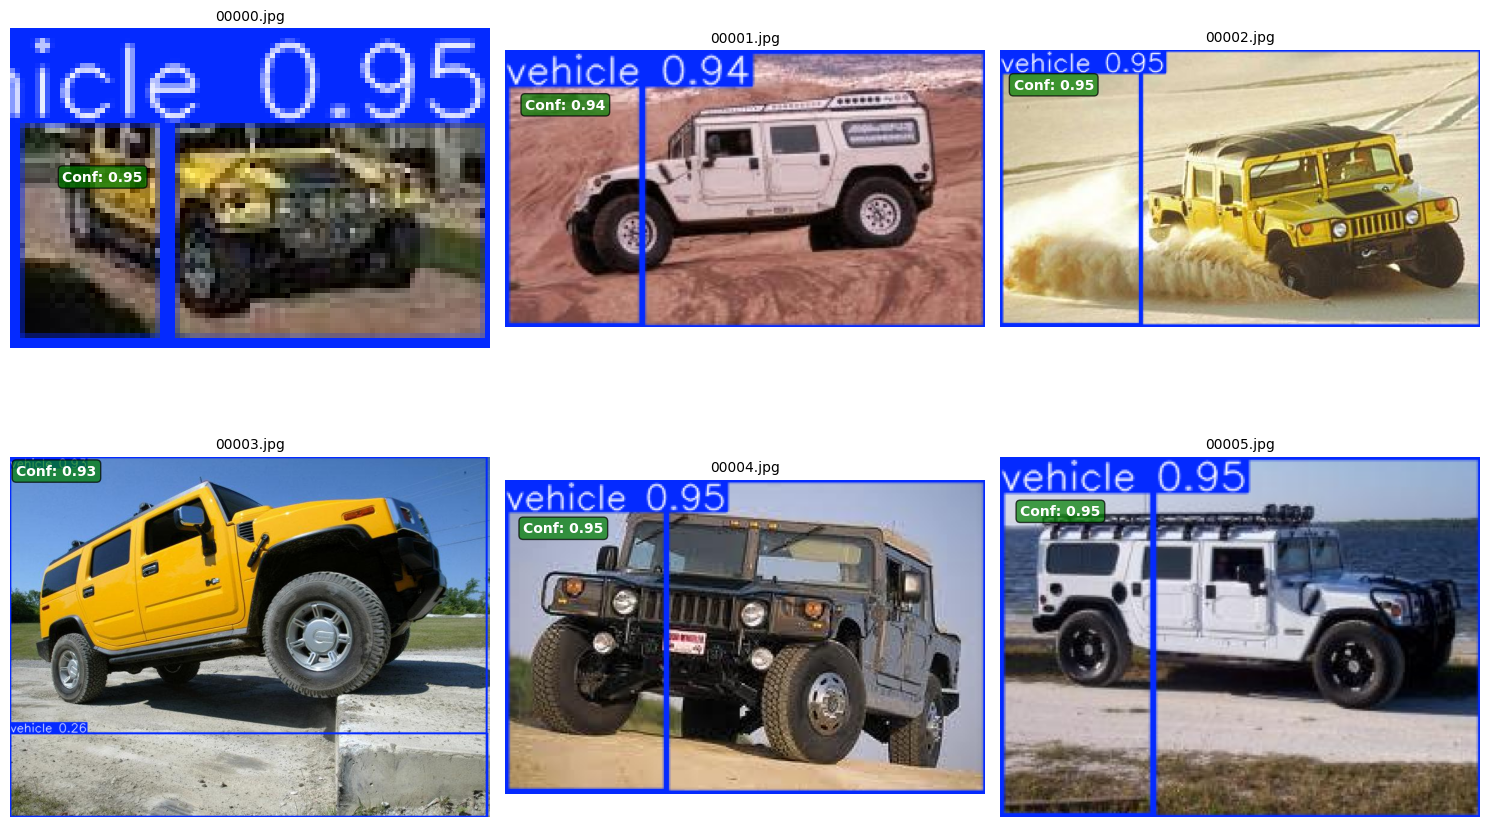


✅ 6/6 images avec détections


In [27]:
# Test sur quelques images
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

test_images = list((DATA_DIR / 'cars_test').glob('*.jpg'))[:6]

print(f'🔍 Test sur {len(test_images)} images')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

images_with_detections = 0

for idx, img_path in enumerate(test_images):
    # Prédire
    results = best_model(str(img_path), conf=0.25, verbose=False)
    
    # DEBUG
    n_boxes = len(results[0].boxes)
    print(f'Image {idx+1}: {img_path.name} → {n_boxes} détection(s)')
    
    # Récupérer image annotée
    annotated_img = results[0].plot()
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # Afficher
    axes[idx].imshow(annotated_img)
    axes[idx].set_title(f'{img_path.name}', fontsize=10)
    axes[idx].axis('off')
    
    # Info détection
    if n_boxes > 0:
        images_with_detections += 1
        conf = results[0].boxes.conf[0].item()
        axes[idx].text(10, 30, f'Conf: {conf:.2f}', 
                      bbox=dict(boxstyle='round', facecolor='green', alpha=0.7),
                      fontsize=10, color='white', weight='bold')
    else:
        axes[idx].text(10, 30, 'Pas de détection', 
                      bbox=dict(boxstyle='round', facecolor='red', alpha=0.7),
                      fontsize=10, color='white', weight='bold')

plt.tight_layout()
plt.show()

print(f'\n✅ {images_with_detections}/{len(test_images)} images avec détections')

## 🎯 Test Pipeline Complet : YOLO + EfficientNet

In [28]:
# Charger EfficientNet
import torch
from src.model import VehicleClassifier
from src.dataset import get_transforms

# Paths - VÉRIFIEZ le nom du dossier
EFFICIENTNET_DIR = Path('models/efficientnet_classifier_v2_production_50epochs')

# Si le dossier n'existe pas, essayer sans le suffixe
if not EFFICIENTNET_DIR.exists():
    print(f'⚠️  Dossier {EFFICIENTNET_DIR} introuvable')
    print('🔍 Recherche du modèle EfficientNet...')
    
    # Chercher dans models/
    for item in Path('models').iterdir():
        if item.is_dir() and 'efficientnet' in item.name:
            print(f'   Trouvé: {item}')
            EFFICIENTNET_DIR = item
            break

EFFICIENTNET_MODEL = EFFICIENTNET_DIR / 'best_model_final.pth'
CLASS_NAMES_FILE = EFFICIENTNET_DIR / 'class_names.json'

print(f'📁 Dossier EfficientNet: {EFFICIENTNET_DIR}')
print(f'📄 Modèle: {EFFICIENTNET_MODEL}')
print(f'📄 Classes: {CLASS_NAMES_FILE}')

# Vérifier existence
if not EFFICIENTNET_MODEL.exists():
    print(f'❌ ERREUR: Modèle introuvable')
else:
    # Charger class names
    with open(CLASS_NAMES_FILE) as f:
        vehicle_classes = json.load(f)

    # Charger modèle
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    classifier = VehicleClassifier(num_classes=len(vehicle_classes), pretrained=False)
    checkpoint = torch.load(EFFICIENTNET_MODEL, map_location=device)
    classifier.load_state_dict(checkpoint['model_state_dict'])
    classifier = classifier.to(device)
    classifier.eval()

    print(f'\n✅ EfficientNet chargé - Val Acc: {checkpoint["val_acc"]:.2f}%')

📁 Dossier EfficientNet: models/efficientnet_classifier_v2_production_50epochs
📄 Modèle: models/efficientnet_classifier_v2_production_50epochs/best_model_final.pth
📄 Classes: models/efficientnet_classifier_v2_production_50epochs/class_names.json

✅ EfficientNet chargé - Val Acc: 81.75%


In [29]:
def predict_pipeline(image_path, yolo_model, classifier, vehicle_classes, device):
    """
    Pipeline complet: YOLO détection → EfficientNet classification
    """
    # 1. Charger image
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 2. Détection YOLO
    yolo_results = yolo_model(image, conf=0.25, verbose=False)
    
    if len(yolo_results[0].boxes) == 0:
        return None, image_rgb, "Aucun véhicule détecté"
    
    # 3. Prendre première détection (plus haute confiance)
    box = yolo_results[0].boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    yolo_conf = float(box.conf[0])
    
    # 4. Crop véhicule
    vehicle_crop = image_rgb[y1:y2, x1:x2]
    
    # 5. Classification EfficientNet
    transform = get_transforms(img_size=224, is_train=False)
    transformed = transform(image=vehicle_crop)['image'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = classifier(transformed)
        probs = torch.softmax(outputs, dim=1)
        top_prob, top_idx = torch.max(probs, 1)
    
    predicted_class = vehicle_classes[top_idx.item()]
    class_conf = top_prob.item()
    
    return {
        'bbox': [x1, y1, x2, y2],
        'yolo_conf': yolo_conf,
        'vehicle_class': predicted_class,
        'class_conf': class_conf,
        'vehicle_crop': vehicle_crop
    }, image_rgb, None

print('✅ Fonction pipeline complète prête')

✅ Fonction pipeline complète prête


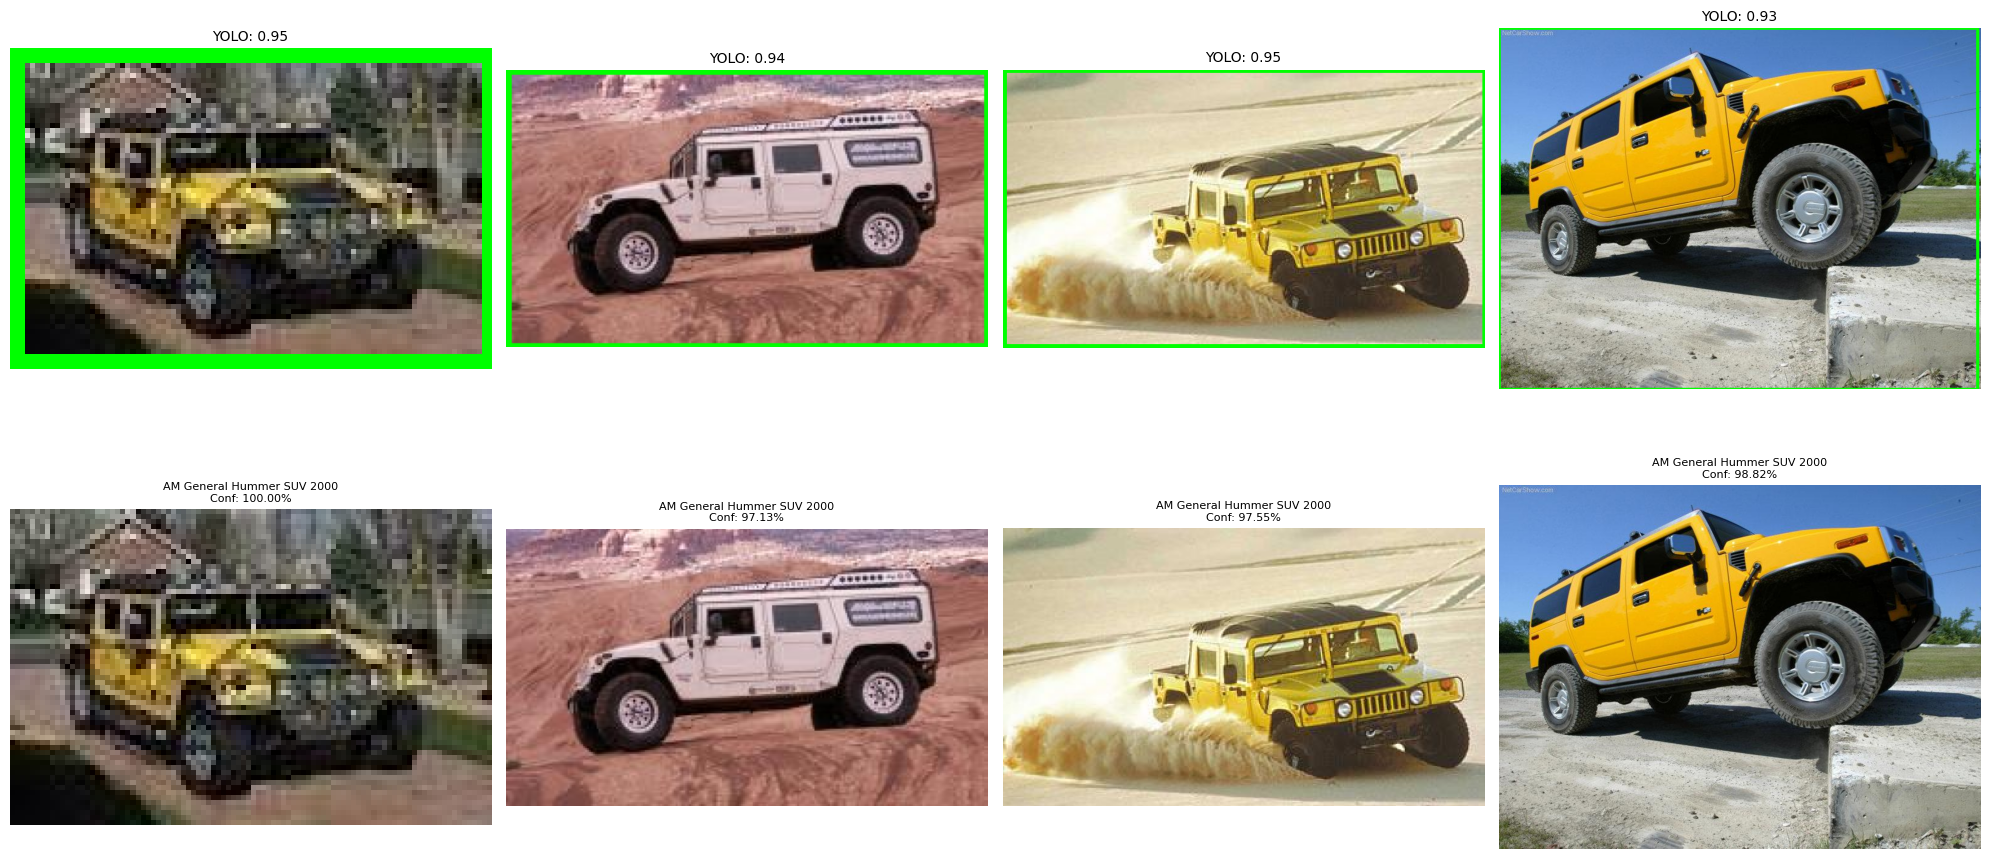


✅ Pipeline complet testé!
📊 Ligne 1: Détection YOLO
📊 Ligne 2: Classification EfficientNet sur crop


In [30]:
# Test pipeline complet sur images
test_images = list((DATA_DIR / 'cars_test').glob('*.jpg'))[:4]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, img_path in enumerate(test_images):
    result, image, error = predict_pipeline(
        img_path, best_model, classifier, vehicle_classes, device
    )
    
    if error:
        continue
    
    # Image complète avec bbox
    ax_full = axes[0, idx]
    img_copy = image.copy()
    x1, y1, x2, y2 = result['bbox']
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3)
    ax_full.imshow(img_copy)
    ax_full.set_title(f'YOLO: {result["yolo_conf"]:.2f}', fontsize=10)
    ax_full.axis('off')
    
    # Crop véhicule avec prédiction
    ax_crop = axes[1, idx]
    ax_crop.imshow(result['vehicle_crop'])
    title = f"{result['vehicle_class'][:35]}\nConf: {result['class_conf']:.2%}"
    ax_crop.set_title(title, fontsize=8)
    ax_crop.axis('off')

plt.tight_layout()
plt.show()

print('\n✅ Pipeline complet testé!')
print('📊 Ligne 1: Détection YOLO')
print('📊 Ligne 2: Classification EfficientNet sur crop')

## ✅ Résumé

Vous avez maintenant :

1. ✅ **YOLOv8 détection véhicule** entraîné
2. ✅ **EfficientNet classification** (81.75% accuracy)
3. ✅ **Pipeline complet** YOLO → Crop → Classification

**Prochaine étape** : Intégrer avec votre système ALPR existant !

---